# Lecture 28: Genetic Algorithm - Algorithm

---

```{note}
Lecture 27 developed the Genetic Algorithm's pseudocode with $\text{SM}$, $\text{CM}$, $\text{MM}$, and $\text{NM}$ left as pluggable operators, and hand-traced one generation on 4-bit strings. This lecture specializes those operators for **real-valued vectors** and applies the result to the same Ackley function Lecture 25 used for Simulated Annealing — the first head-to-head hint of how these two paradigms behave on identical ground.
```

**Learning Objectives**

By the end of this notebook, you will be able to:
1. Implement selection, crossover, and mutation operators for real-valued solutions.
2. Run a Genetic Algorithm on a continuous test function and interpret its convergence.
3. Compare a population-based search's convergence behaviour to Simulated Annealing's.

**Prerequisites**: Genetic Algorithm - Motivation & Pseudocode (Lecture 27); Simulated Annealing - Algorithm (Lecture 25).

**Estimated time**: 50 minutes

---

## From Pseudocode to Python

The engine below is a direct translation of Lecture 27's pseudocode — like `sa()` in Lecture 25, it makes no assumption about what a solution looks like, only that `f`, `SM`, `CM`, `MM`, and `NM` are supplied. **This is the same engine Lecture 29 will reuse unchanged for its calibration study** — only the operators plugged into it will ever change.

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

def ga(S_o, f, SM, u, CM, l, p, MM, e, NM, n=500, t=1e-8):
    """Genetic Algorithm.

    Parameters
    ----------
    S_o : initial population (list of solutions)
    f   : objective function, f(s) -> float (minimized)
    SM  : selection method, SM(S, u, f) -> u parents
    CM  : crossover method, CM(parents, l, p) -> l offspring, p parents per offspring
    MM  : mutation method, MM(offspring, e) -> mutated offspring (probability e each)
    NM  : natural selection, NM(S, m, f) -> next generation of size m
    n   : maximum number of generations
    t   : convergence threshold on improvement in the best solution
    """
    S = S_o
    s_b = min(S, key=f)                # best solution found so far
    F_b = [f(s_b)]
    k, r, converged = 0, float("inf"), False
    while not converged:
        S_p = SM(S, u, f)                       # select parents
        S_c = CM(S_p, l, p)                     # crossover -> offspring
        S_c = MM(S_c, e)                        # mutate offspring
        S = NM(S + S_c, len(S_o), f)             # replace: parents + offspring -> next population
        s_p = min(S, key=f)
        if f(s_p) < f(s_b):
            r = f(s_b) - f(s_p)
            s_b = s_p
        F_b.append(f(s_b))
        k += 1
        if k >= n or r <= t:
            converged = True
    return s_b, F_b

def ackley(s):
    x, y = s
    return (-20 * np.exp(-0.2 * np.sqrt((x ** 2 + y ** 2) / 2))
            - np.exp((np.cos(2 * np.pi * x) + np.cos(2 * np.pi * y)) / 2)
            + 20 + np.e)

print("ga() and ackley() defined.")

ga() and ackley() defined.


## Real-Valued Operators

Applying `ga()` to the Ackley function needs operators suited to real-valued vectors:

- **Selection**: *roulette-wheel selection* — probability of selection proportional to fitness $1/(1+f(s))$.
- **Crossover**: *arithmetic (blend) crossover* — a child is a random weighted average of its parents' coordinates, drawn from a Dirichlet distribution so the weights sum to 1.
- **Mutation**: *Gaussian mutation* — with probability $\epsilon$, add Gaussian noise to each coordinate.

```{note}
Compare this to Lecture 27's 4-bit hand-trace: single-point crossover made sense there because *any* combination of bits is a valid bit string. A real-valued vector has no such freedom to "cut and splice" arbitrarily — averaging two parents' coordinates is the natural analogue, and (as Lecture 29 will contrast directly) neither of these operators would make sense applied to a permutation.
```

In [2]:
def SM_roulette(S, u, f):
    """Roulette-wheel selection: probability of selection proportional to 1/(1+f(s))."""
    fitness = np.array([1.0 / (1.0 + f(s)) for s in S])
    weights = fitness / fitness.sum()
    idx = np.random.choice(len(S), size=u, p=weights)
    return [S[i] for i in idx]

def CM_arith(S_p, l, p):
    """Arithmetic (blend) crossover: a Dirichlet-weighted average of p parents."""
    S_c = []
    for _ in range(l):
        parents = random.sample(S_p, p)
        w = np.random.dirichlet(np.ones(p))
        x = sum(wi * pi[0] for wi, pi in zip(w, parents))
        y = sum(wi * pi[1] for wi, pi in zip(w, parents))
        S_c.append((x, y))
    return S_c

def MM_gauss(S_c, e, sigma=0.3):
    """Gaussian mutation: with probability e, add N(0, sigma) noise to each coordinate."""
    out = []
    for (x, y) in S_c:
        if random.random() < e:
            x += random.gauss(0, sigma)
            y += random.gauss(0, sigma)
        out.append((x, y))
    return out

def NM_elitist(S, m, f):
    """Elitist replacement: keep the m fittest solutions from parents + offspring."""
    return sorted(S, key=f)[:m]

print("Real-valued operators defined.")

Real-valued operators defined.


## Applying the Genetic Algorithm

In [3]:
random.seed(42)
np.random.seed(42)
S_o = [(random.uniform(-5, 5), random.uniform(-5, 5)) for _ in range(30)]
print("Initial population size:", len(S_o))
print("Best in initial population:", round(min(ackley(s) for s in S_o), 5))

random.seed(42)
np.random.seed(42)
s_b, F_b = ga(S_o, ackley, SM_roulette, 20, CM_arith, 20, 2, MM_gauss, 0.3, NM_elitist, n=200, t=1e-12)
print("\nBest point found:", tuple(round(v, 4) for v in s_b))
print("Best f found:", round(ackley(s_b), 5), " (global optimum: f(0,0) = 0)")

Initial population size: 30
Best in initial population: 5.44749

Best point found: (np.float64(-0.0195), np.float64(0.0096))
Best f found: 0.07409  (global optimum: f(0,0) = 0)


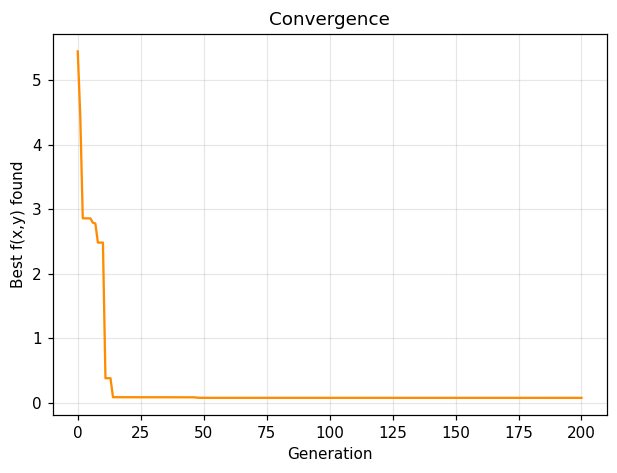

In [4]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(F_b, color="darkorange", linewidth=1.5)
ax.set_xlabel("Generation")
ax.set_ylabel("Best f(x,y) found")
ax.set_title("Convergence")
ax.grid(alpha=0.3)
plt.show()

```{tip}
Compare this convergence plot's shape to Lecture 25's: Simulated Annealing's curve is one continuous descent (a single solution improving); the Genetic Algorithm's curve reflects a *population's* best member each generation — with 30 candidate solutions evaluated per generation instead of 1 per iteration, GA typically needs far fewer generations to reach a comparable result, at the cost of far more function evaluations per generation. Lecture 29 studies this cost directly.
```

---

## In-Class Exercise

### Exercise 1 — Does the Selection Method Matter?

Replace roulette-wheel selection with **tournament selection**, which repeatedly samples a small group and keeps the fittest, and compare the result on the same starting population and random seed.

In [5]:
def SM_tournament(S, u, f, k=3):
    """Tournament selection: repeatedly keep the fittest of a random group of size k."""
    return [min(random.sample(S, k), key=f) for _ in range(u)]

random.seed(42)
np.random.seed(42)
s_b_t, F_b_t = ga(S_o, ackley, SM_tournament, 20, CM_arith, 20, 2, MM_gauss, 0.3, NM_elitist, n=200, t=1e-12)

print("roulette   best f:", round(ackley(s_b), 5))
print("tournament best f:", round(ackley(s_b_t), 5))

roulette   best f: 0.07409
tournament best f: 0.02395


**Interpretation.** Tournament selection reaches a noticeably better result here. With Ackley's objective values for a population scattered around the landscape often within a similar range, $1/(1+f(s))$ assigns fairly similar weights to good and mediocre solutions alike — weak selection pressure, closer to picking parents at random. Tournament selection, by contrast, always favours the better of a small sampled group regardless of the absolute fitness values, giving more consistent pressure toward the fitter solutions. **Selection pressure, not just the crossover and mutation operators, shapes how effectively a Genetic Algorithm converges** — Lecture 29 studies this alongside population size and mutation rate.

---

## Take-Away Exercises

### Exercise 1 — Crossover Parent Count

This lecture's `CM_arith` combines $p=2$ parents per offspring. Modify it to support $p=3$ or $p=4$ parents (the Dirichlet-weighted average already generalizes to any $p$), and re-run the main demo. Does combining more parents per offspring help, hurt, or make little difference?

### Exercise 2 — Mutation Rate

Sweep the mutation probability $\epsilon \in \{0.0, 0.1, 0.3, 0.6\}$ with tournament selection. Does mutation help here the way it helped Lecture 27's hand-traced example escape its local trap?

---

## Circling Back

- **Lecture 27 (Genetic Algorithm: Motivation & Pseudocode)**: `ga()` above is a direct translation of that lecture's pseudocode; `SM_roulette`, `CM_arith`, `MM_gauss`, and `NM_elitist` are concrete instances of $\text{SM}$, $\text{CM}$, $\text{MM}$, and $\text{NM}$.
- **Lecture 25 (Simulated Annealing: Algorithm)**: solves the identical Ackley function — compare the two convergence plots directly for a first look at how a single-solution search and a population search differ in shape.

## Moving Forward

- **Lecture 29 (Genetic Algorithm: Benchmarking)**: calibrates population size and mutation rate on this same Ackley function, then asks whether the calibrated settings transfer to a routing problem with entirely different operators.

---

## Further Reading

- Holland, J.H. (1975). *Adaptation in Natural and Artificial Systems*. University of Michigan Press — the foundational text introducing genetic algorithms.
- Herrera, F., Lozano, M., and Verdegay, J.L. (1998). "Tackling Real-Coded Genetic Algorithms: Operators and Tools for Behavioural Analysis." *Artificial Intelligence Review*, 12(4), 265-319 — real-valued crossover and mutation operators surveyed in depth.
- Goldberg, D.E. and Deb, K. (1991). "A Comparative Analysis of Selection Schemes Used in Genetic Algorithms." *Foundations of Genetic Algorithms*, 1, 69-93 — selection pressure compared across selection methods.